# 06 · Observable Evidence `Z` & Drift

KGA's decision uses only **label-free** signals computed from validation + test scores:
validation AUROC gap, score-distribution **drift** (KS, val→test), **detector disagreement**,
score sharpness, anomaly rate. This notebook computes them live and shows which matters most.


In [1]:
import os, json, glob, numpy as np
REPO=os.path.abspath(os.getcwd())
while REPO!='/' and not os.path.exists(os.path.join(REPO,'scripts','rebuild_kbound.sh')): REPO=os.path.dirname(REPO)
RES=os.path.join(REPO,'experiments','kbound','results'); FIG=os.path.join(REPO,'docs','research','kbound','figures')
ARCH=os.path.join(REPO,'experiments','elara_u','score_archive'); ELA=os.path.join(REPO,'experiments','elara_u')
from IPython.display import Image, display
def jload(p):
    fp=p if os.path.isabs(p) else os.path.join(RES,p)
    return json.load(open(fp)) if os.path.exists(fp) else {}
def fig(fn,w=720):
    p=os.path.join(FIG,fn)
    if os.path.exists(p): display(Image(filename=p,width=w))
print('repo:',REPO)
from scipy.stats import ks_2samp, rankdata

repo: /sessions/optimistic-amazing-ritchie/mnt/uav/AutoML_Flagship_V8


In [2]:
def rn(S):
    R=np.empty_like(S,dtype=float)
    for j in range(S.shape[1]): R[:,j]=(rankdata(S[:,j])-1)/(len(S)-1)
    return R
feat=['val_max','val_gap','ks_mean','ks_max','disagree','anomaly_rate']; Zs=[]
for f in sorted(glob.glob(ARCH+'/*.npz')):
    d=np.load(f,allow_pickle=True); Sv,yv,St,va=d['Sval'],d['yval'],d['Stest'],d['val_auc']
    ks=[ks_2samp(Sv[:,k],St[:,k]).statistic for k in range(Sv.shape[1])]
    Rt=rn(St); C=np.corrcoef(Rt.T); iu=np.triu_indices_from(C,k=1); vs=np.sort(va)[::-1]
    Zs.append([float(vs[0]),float(vs[0]-vs[1]),float(np.mean(ks)),float(np.max(ks)),float(1-np.nanmean(C[iu])),float(np.mean(yv))])
Z=np.array(Zs)
print('label-free evidence over %d tasks (mean +/- std):'%len(Z))
for i,name in enumerate(feat): print('  %-12s %.3f +/- %.3f'%(name,Z[:,i].mean(),Z[:,i].std()))

label-free evidence over 123 tasks (mean +/- std):
  val_max      0.758 +/- 0.147
  val_gap      0.024 +/- 0.030
  ks_mean      0.052 +/- 0.048
  ks_max       0.068 +/- 0.065
  disagree     0.225 +/- 0.134
  anomaly_rate 0.107 +/- 0.107


### Which evidence feature drives the decision?
From the ablation (drop-one-feature; higher regret ⇒ more important): **detector disagreement**
dominates — consistent with Theorem 5 (the decision lives on the disagreement region).


  disagree         regret 0.094
  val_mean         regret 0.043
  log_ntest        regret 0.039
  ks_max           regret 0.037
  val_gap          regret 0.037
  anomaly_rate     regret 0.037


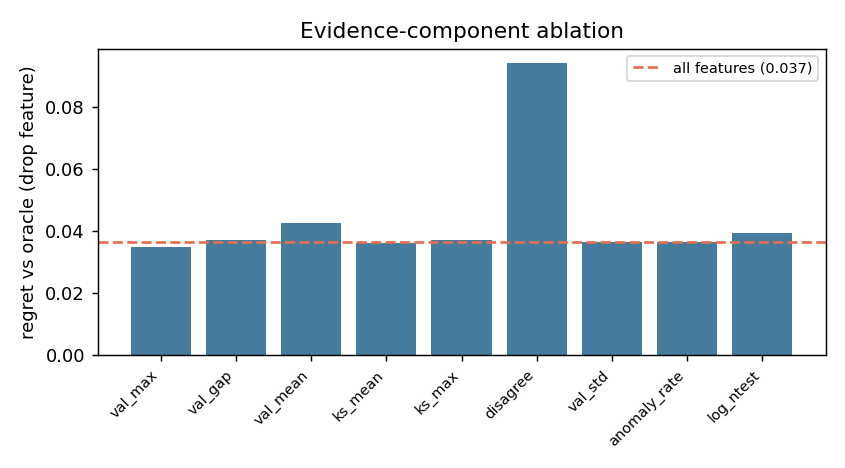

In [3]:
a=jload('ablations.json')
for k,v in sorted(a.get('evidence_drop',{}).items(),key=lambda x:-x[1]['regret'])[:6]: print('  %-16s regret %.3f'%(k,v['regret']))
fig('fig_ablation_evidence.png')

**Caveat (Thm 2 / ELARA T2).** Global KS drift can *false-fire* under benign mixture re-weighting
even with no real degradation — an observability hazard that pushes ambiguous cases toward **abstain**.
